---
title: "Exploratory Data Analysis of Diario Oficial Titles, 1917–2025"
subtitle: "A first exploration of the note archive"
date: 2026-07-17
# author:
#  - name: INGEOTEC
abstract: >
  We examine the titles of the 1,221,451 notes published in Mexico's Diario
  Oficial de la Federación between January 1917 and December 2025, obtained from
  the gazette's own open-data service. The analysis of yearly volume, of the
  first word of each title, of title length and of vocabulary reveals three
  major transformations: the expansion of the gazette from 1999 onward, when
  the systematic cataloguing of procurement announcements and notices doubled
  the number of notes; the displacement of the classic legal instruments —
  resoluciones and decretos — by the administrative aviso as the dominant
  documentary form; and the correlative impoverishment of the title as a
  descriptor, whose median length fell from about twenty words to six.
---

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/INGEOTEC/LegalIA/blob/master/website/explorations/titles.ipynb)


In [1]:
#| label: setup
#| include: false
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go

# The aggregated CSVs live next to the site's sources; when this notebook runs
# elsewhere (e.g. Google Colab) they are fetched from the repository instead.
DATA_DIR = Path("../data")
DATA_URL = "https://raw.githubusercontent.com/INGEOTEC/LegalIA/master/website/data"


def load(name):
    local = DATA_DIR / name
    return pd.read_csv(local if local.exists() else f"{DATA_URL}/{name}")


# Validated categorical palette (light mode), in fixed assignment order.
BLUE, GREEN, MAGENTA, YELLOW = "#2a78d6", "#008300", "#e87ba4", "#eda100"
LIGHT_BLUE = "#9ec5f4"  # step 200 of the blue sequential ramp
INK, MUTED, GRID, AXIS = "#52514e", "#898781", "#e1e0d9", "#c3c2b7"

mpl.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": AXIS,
        "axes.labelcolor": INK,
        "axes.titlecolor": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "text.color": INK,
        "font.size": 10,
        "axes.axisbelow": True,
    }
)


def clean_axis(ax):
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.tick_params(length=0)
    ax.set_xlabel("")


def thousands(x, _):
    return f"{int(x):,}"


# Shared Plotly styling, mirroring the matplotlib figures' academic look: a white
# surface, a light horizontal grid only, no spines, muted ticks, ink-colored text
# and a unified hover box. Reused by every interactive figure on this page.
PLOTLY_FONT = "system-ui, -apple-system, 'Segoe UI', Helvetica, Arial, sans-serif"


def style_plotly(fig, *, yaxis_title="", height=430):
    fig.update_layout(
        font=dict(family=PLOTLY_FONT, size=13, color=INK),
        paper_bgcolor="white",
        plot_bgcolor="white",
        height=height,
        margin=dict(l=64, r=24, t=16, b=40),
        hovermode="x unified",
        hoverlabel=dict(bgcolor="white", bordercolor=GRID, font=dict(color=INK, size=12)),
        legend=dict(font=dict(size=12, color=INK)),
    )
    fig.update_xaxes(
        showgrid=False, showline=False, zeroline=False,
        ticks="", tickfont=dict(color=MUTED), title_text="",
    )
    fig.update_yaxes(
        showgrid=True, gridcolor=GRID, gridwidth=1,
        showline=False, zeroline=False,
        ticks="", tickfont=dict(color=MUTED),
        title_text=yaxis_title, title_font=dict(color=INK, size=13),
    )
    return fig


notes = load("notes_per_year.csv")
days = load("days_with_notes.csv")
length = load("title_length.csv")
first_words = load("first_words.csv")
headings = load("headings.csv")
terms = load("terms_by_decade.csv")

per_year = notes.groupby("year").notes.sum()

## The title as an object of study

Every note in the *Diario Oficial de la Federación* is born with a title.
Before there is any digitized full text, OCR or structural markup, the title
is the only descriptor that accompanies each document across the entire
archive: it says what kind of instrument is being published, who issues it and
what it is about. That is why this first exploration deals exclusively with
that minimal piece of metadata. If titles allow us to reconstruct, even in
broad strokes, the documentary history of the gazette, then they are a solid
foundation for the classification and retrieval tasks that will follow.

The material comes from the DOF's open-data service, from which the daily
summary of notes was downloaded for every day between January 1, 1917 and
December 31, 2025. The result is 1,221,451 notes spread over 30,486 publication
days: the gazette appears, on average, 280 days a year — practically every
business day. A methodological caveat is in order: the metadata for the decades
before digitization was captured retrospectively by the gazette itself, so the
unit *note* reflects cataloguing criteria that are not constant over time. Part
of what follows documents precisely those changes of criteria.

## How many notes the State publishes

The yearly series of the number of notes divides the recent history of the
gazette in two ([@fig-volume]). For most of the twentieth century — from 1917
until the late 1990s — the DOF published on the order of five thousand notes a
year, drifting upward toward the end of the century, with swings that track the
six-year presidential cycles but no sustained trend. In 1999 the volume jumps
from 12,921 to 28,238 notes — more than double — and never comes back: the
2010s settle above thirty thousand notes a year, peaking at 36,041 in 2014. The
jump does not reflect a legislative explosion but a change in cataloguing: as
will become clear below, this is the moment when procurement announcements and
judicial and general notices — which had always existed in the gazette's pages
— begin to be recorded as individual notes in the electronic system.

In [2]:
#| label: fig-volume
#| fig-cap: "Notes published in the DOF per year, 1917\u20132025. Hover on a bar to read the exact count for that year."
fig = go.Figure(
    go.Bar(
        x=per_year.index,
        y=per_year.values,
        marker=dict(color=BLUE, cornerradius=2),
        hovertemplate="%{y:,} notes<extra></extra>",
        name="Notes published",
    )
)
style_plotly(fig, yaxis_title="Notes published")
fig.update_yaxes(tickformat=",")
fig.update_layout(bargap=0.2, showlegend=False)
fig.show(
    config={
        "displaylogo": False,
        "displayModeBar": "hover",
        "modeBarButtonsToRemove": ["lasso2d", "select2d", "autoScale2d"],
    }
)

Two recent episodes deserve mention. The decline that bottoms out in 2020 —
19,889 notes, down from more than thirty thousand two years earlier — coincides
with the change of federal government, its austerity policy and, in 2020, the
suspension of activities during the COVID-19 pandemic; the subsequent recovery
is only partial. The evening edition, which the archive registers only from the
late 1980s onward, remains marginal: 3,021 notes over the whole period, about
two in every thousand, although its use has become more frequent in the current
decade.

## The first word: a de facto documentary typology

DOF titles follow a stable convention: they open with the name of the
instrument being published — "DECRETO por el que…" (*decree whereby…*),
"ACUERDO que establece…" (*agreement establishing…*), "AVISO de…" (*notice
of…*) — or, in the announcement sections, with the name of the convening
body. The first word of the title thus works as a de facto documentary
typology, and its evolution summarizes more than a century of administrative
history ([@fig-instruments]).

In [3]:
#| label: fig-instruments
#| fig-cap: "Yearly share of the four most telling first words in DOF titles: resoluci\u00f3n (resolution), decreto (decree), acuerdo (agreement) and aviso (notice). Each series is labeled directly on its curve; hover to read every share for a year, or use the legend to isolate one."
selection = {
    "RESOLUCION": ("Resoluci\u00f3n", BLUE),
    "DECRETO": ("Decreto", GREEN),
    "ACUERDO": ("Acuerdo", MAGENTA),
    "AVISO": ("Aviso", YELLOW),
}

piv = first_words.pivot_table(index="year", columns="word", values="notes", aggfunc="sum").fillna(0)
share = piv.div(piv.sum(axis=1), axis=0) * 100

# Vertical offset (in pixels) so labels of series that end at almost the same
# level do not overlap.
dodge = {"DECRETO": 8, "RESOLUCION": -6}
fig = go.Figure()
for word, (label, color) in selection.items():
    s = share[word]
    fig.add_trace(
        go.Scatter(
            x=s.index,
            y=s.values,
            name=label,
            mode="lines",
            line=dict(color=color, width=2),
            hovertemplate="%{fullData.name}: %{y:.1f}%<extra></extra>",
        )
    )
    fig.add_annotation(
        x=s.index[-1],
        y=s.values[-1],
        text=label,
        xanchor="left",
        xshift=6,
        yshift=dodge.get(word, 0),
        showarrow=False,
        font=dict(color=color, size=11),
    )

style_plotly(fig, yaxis_title="Share of the year's notes (%)")
fig.update_xaxes(range=[1917, 2031])
fig.update_layout(
    margin=dict(l=64, r=96, t=32, b=40),
    legend=dict(orientation="h", yanchor="bottom", y=1.0, xanchor="center", x=0.5),
)
fig.show(
    config={
        "displaylogo": False,
        "displayModeBar": "hover",
        "modeBarButtonsToRemove": ["lasso2d", "select2d", "autoScale2d"],
    }
)

For most of the twentieth century the word *Resolución* opened a large share of
the titles — around four in every ten in 1975, and even more in the
land-reform decades before that. These were not just any administrative
resolutions: they were, overwhelmingly, agrarian resolutions — grants and
extensions of *ejidos* (communal landholdings), deprivations of agrarian
rights, creations of new population centers — the daily paperwork of Mexico's
land reform. As land distribution wound down and the 1992 reform of Article 27
of the Constitution closed the era, that documentary mass vanishes: by 2025
resolutions barely reach one percent of the notes. The *Decreto*, the classic
form of presidential action, follows a similar though less abrupt trajectory,
from eleven percent in 1975 to little more than one.

The opposite movement belongs to the *Aviso*. Practically absent for most of
the century — under one percent of the titles — it is today the first word of
43.8 percent of the notes, and of 22.1 percent over the whole period. If avisos
are added to acuerdos, resoluciones, decretos, convenios, circulares and
declaratorias, almost half of the titles in the archive open with one of these
seven instruments; the rest correspond mostly to titles that open with the name
of an institution — *Instituto*, *Secretaría*, *Comisión*, *Pemex* — the
signature of procurement and job-opening announcements.

## Titles that shrink

The change in documentary composition left a sharp imprint on the very shape
of the titles ([@fig-length]). For most of the century the median title ran to
around twenty words, rising to about twenty-five in the 1970s and 1980s: the
typical agrarian resolution named the village, the municipality and the state
involved, in addition to the nature of the proceeding. From 1999 onward the
median collapses and settles at six words. The explanation is not that legal
instruments are named more economically today, but once again composition: the
announcements and notices that flood the gazette from then on carry minimal
titles — the agency's name followed by a docket number, as in "INSTITUTO
MEXICANO DEL SEGURO SOCIAL - REF:501748" — which drag the distribution down.
The mean, more sensitive to the long titles that survive among normative
instruments, declines less severely.

In [4]:
#| label: fig-length
#| fig-cap: "Title length in words: yearly mean and median, 1917\u20132025. Hover to read both statistics for a year."
fig = go.Figure()
for label, col, color in [("Mean", "words_mean", BLUE), ("Median", "words_median", GREEN)]:
    fig.add_trace(
        go.Scatter(
            x=length.year,
            y=length[col],
            name=label,
            mode="lines",
            line=dict(color=color, width=2),
            hovertemplate="%{fullData.name}: %{y:.1f} words<extra></extra>",
        )
    )
    fig.add_annotation(
        x=length.year.iloc[-1],
        y=length[col].iloc[-1],
        text=label,
        xanchor="left",
        xshift=6,
        showarrow=False,
        font=dict(color=color, size=11),
    )

style_plotly(fig, yaxis_title="Words per title", height=400)
fig.update_xaxes(range=[1917, 2030])
fig.update_yaxes(rangemode="tozero")
fig.update_layout(
    margin=dict(l=64, r=80, t=16, b=40),
    legend=dict(yanchor="top", y=0.98, xanchor="right", x=0.98),
)
fig.show(
    config={
        "displaylogo": False,
        "displayModeBar": "hover",
        "modeBarButtonsToRemove": ["lasso2d", "select2d", "autoScale2d"],
    }
)

## Who fills the gazette's pages

The archive files each note under a top-level heading that mixes branches of
government with fixed sections of the gazette. Its evolution confirms the
reading above ([@fig-sections]): for its first seven decades the gazette was,
in terms of notes, almost exclusively the bulletin of the Executive Branch. The
section for public procurement announcements appears in 1988 and the one for
judicial and general notices in 1996; a decade later the two together already
account for more than half of each year's notes. The Executive, without
reducing its output in absolute terms, ended up surrounded by the paperwork of
public contracting and private-party notices.

In [5]:
#| label: fig-sections
#| fig-cap: "Yearly composition of the notes by the archive's top-level heading, 1917\u20132025. Hover on a year to read each band's exact share; use the legend to isolate a section."
PROCUREMENT = (
    "CONVOCATORIAS PARA CONCURSOS DE ADQUISICIONES, ARRENDAMIENTOS, "
    "OBRAS Y SERVICIOS DEL SECTOR PUBLICO"
)
groups = {
    "PODER EJECUTIVO": "Executive Branch",
    PROCUREMENT: "Procurement announcements",
    "AVISOS JUDICIALES Y GENERALES": "Judicial and general notices",
}
headings["group"] = headings.heading.map(groups).fillna("Other")
comp = headings.pivot_table(index="year", columns="group", values="notes", aggfunc="sum").fillna(0)
order = ["Executive Branch", "Procurement announcements", "Judicial and general notices", "Other"]
comp = comp[order].div(comp.sum(axis=1), axis=0) * 100
palette = dict(zip(order, [BLUE, GREEN, MAGENTA, YELLOW]))

# One stacked area per section, in the fixed palette order (first trace at the
# bottom). A thin white line on each band's top edge is the surface gap that keeps
# adjacent fills legible.
fig = go.Figure()
for name in order:
    fig.add_trace(
        go.Scatter(
            x=comp.index,
            y=comp[name],
            name=name,
            mode="lines",
            stackgroup="one",
            fillcolor=palette[name],
            line=dict(color="white", width=1.2),
            hovertemplate="%{fullData.name}: %{y:.1f}%<extra></extra>",
        )
    )

style_plotly(fig, yaxis_title="Share of the year's notes (%)")
fig.update_xaxes(range=[1917, 2025])
fig.update_yaxes(range=[0, 100])
fig.update_layout(
    legend=dict(
        x=0.012, y=0.012, xanchor="left", yanchor="bottom",
        bgcolor="rgba(255,255,255,0.92)", bordercolor="rgba(0,0,0,0)",
    )
)
fig.show(
    config={
        "displaylogo": False,
        "displayModeBar": "hover",
        "modeBarButtonsToRemove": ["lasso2d", "select2d", "autoScale2d"],
    }
)

## The vocabulary of each era

One last look, now at the full lexicon of the titles. [@tbl-terms] presents
the ten most frequent terms of each decade — Spanish words, since that is the
language of the gazette — after removing function words and the administrative
docket marker "REF" that accompanies the announcements. The earliest decades,
those of the aftermath of the Revolution, speak of water and property:
*aguas* (waters), *río* (river), *propiedad* (property), *aprovechamiento*
(usufruct). From the 1930s the vocabulary of land reform takes over —
*poblado* (village), *ejido*, *dotación* (land grant), *inafectabilidad*
(exemption from expropriation), *municipio* (municipality), *derechos agrarios*
(agrarian rights) — and dominates through the 1980s. It fades in the 1990s,
when generic institutional terms — *nacional*, *federal*, *estados unidos
mexicanos* — take its place. From the 2000s onward the gazette speaks the
language of administration: *aviso*, *secretaría*, *instituto*, *seguro social*,
*servicios*. In little over a century, the DOF went from recording the disputes
over water and land in the wake of the Revolution to documenting the day-to-day
operation of the state apparatus.

In [6]:
#| label: tbl-terms
#| tbl-cap: "The ten most frequent terms in DOF titles by decade (function words and the REF docket marker excluded; the 1910s begin in 1917 and the 2020s run through 2025)."
from IPython.display import Markdown

decades = sorted(terms.decade.unique())
top = {d: terms[terms.decade == d].head(10).term.tolist() for d in decades}
rows = []
for i in range(10):
    rows.append("| " + str(i + 1) + " | " + " | ".join(top[d][i] for d in decades) + " |")
header = "| # | " + " | ".join(f"{d}s" for d in decades) + " |"
separator = "|---" * (len(decades) + 1) + "|"
Markdown("\n".join([header, separator] + rows))

| # | 1910s | 1920s | 1930s | 1940s | 1950s | 1960s | 1970s | 1980s | 1990s | 2000s | 2010s | 2020s |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 1 | estado | estado | estado | acuerdo | poblado | poblado | municipio | municipio | municipio | aviso | aviso | aviso |
| 2 | aguas | aguas | expediente | inafectabilidad | acuerdo | resolucion | resolucion | denominado | aviso | estado | secretaria | nacional |
| 3 | senor | senor | resolucion | poblado | resolucion | numero | denominado | poblado | nacional | federal | estado | secretaria |
| 4 | rio | rio | poblado | resolucion | inafectabilidad | solicitud | poblado | resolucion | federal | nacional | nacional | instituto |
| 5 | propiedad | solicitud | dotacion | estado | numero | agricola | ejido | ubicado | estados | instituto | instituto | estado |
| 6 | dia | aprovechar | ejidos | expediente | senor | centro | derechos | reg | unidos | secretaria | federal | federal |
| 7 | sesion | presentada | senor | ejidos | solicitud | poblacion | agrarios | acuerdo | acuerdo | pemex | social | social |
| 8 | acta | cancelacion | decreto | predio | san | creacion | privacion | ejido | distrito | comision | municipio | acuerdo |
| 9 | declaracion | fiscal | san | senor | predio | acuerdo | dotacion | derechos | decreto | social | comision | mexicano |
| 10 | solicitud | registro | numero | dotacion | ejido | vecinos | numero | agrarios | mexicanos | produccion | acuerdo | servicios |

## The words that set a year apart

The figures so far read the archive as a whole. A sharper, more political
question is which words *identify* a single year — set it apart from every
other year of the gazette. A new administration arrives with its own
programs, priorities and turns of phrase, and the daily paperwork of the
*Diario Oficial* registers them almost at once. To surface that, we contrast
the vocabulary of one year against the vocabulary of all the others.

This needs the title strings themselves, not the pre-aggregated CSVs the
figures above are built from.
[`dofjson.titulos.download_titulos`](https://pypi.org/project/dofjson/) pulls
them straight from the `notas-archivo` release into one compact
`codNota` + `titulo` + `fecha` dataset (no local checkout of the raw archive,
which keeps the step reproducible on Colab); we then stream it back with
microtc's `tweet_iterator`, grouping the titles by the year of each note's
`fecha`, restricted to 1917–2025 to match the rest of this page.

In [7]:
# On Colab, install the packages this section needs:
# %pip install dofjson microtc wordcloud

In [8]:
#| code-summary: "Download the titles and group them by year"
from collections import defaultdict

from dofjson.titulos import download_titulos
from microtc.utils import tweet_iterator

dest = download_titulos(Path("titulos.jsonl.gz"), log=lambda *_: None)

titles_by_year = defaultdict(list)
for nota in tweet_iterator(str(dest)):
    year = int(nota["fecha"].split("-")[-1])
    if year <= 2025:  # keep the page's 1917–2025 scope
        titles_by_year[year].append(nota["titulo"])

The contrast is a tf-idf comparison built with two
[microtc](https://github.com/INGEOTEC/microtc) `TextModel`s: one fitted on
the target year's titles (each title a document) and one on every other
year's titles. A term's inverse document frequency (idf, exposed as
`token_weight`) is high when the term is rare across a model's documents and
low when it is common. Dividing a term's idf in the *rest* model by its idf
in the *year* model therefore yields a score that is large exactly when the
term is rare in the rest of the archive yet common in the target year — that
is, when it identifies the year. We keep accents (`del_diac=False`), drop
numbers (`num_option="delete"`) and discard one-off vocabulary appearing in
four documents or fewer (`token_min_filter=4`).

In [9]:
#| code-summary: "Score the terms that identify a year"
from microtc.textmodel import TextModel


def pesos_discriminantes(year, **params):
    """idf ratio (rest / year) per shared token: large => identifies `year`."""
    titulos_year = titles_by_year[year]
    titulos_rest = []
    for y, titulos in titles_by_year.items():
        if y != year:
            titulos_rest.extend(titulos)

    tm_year = TextModel(**params).fit(titulos_year)
    tm_rest = TextModel(**params).fit(titulos_rest)

    w_year = {tm_year.id2token[i]: tm_year.token_weight[i] for i in range(tm_year.num_terms)}
    w_rest = {tm_rest.id2token[i]: tm_rest.token_weight[i] for i in range(tm_rest.num_terms)}

    return {tok: w_rest[tok] / w_year[tok]
            for tok in w_year if tok in w_rest and w_year[tok] > 0}

We apply it to the first full year of the two most recent presidencies —
2019, the first year of Andrés Manuel López Obrador, and 2025, the first year
of Claudia Sheinbaum ([@fig-first-year]). Each cloud sizes a term by how
strongly it identifies its year. Beside the gazette's ever-present
administrative markers (*ref*, *aviso*), the year-specific vocabulary comes
through: *snidrus*, *fortaseg*, *electricistas* and the *LXIV* legislature for
2019; *niñez*, *adolescencia*, *afromexicanas*, *violencias*,
*simplificación*, *bienestar* and *presidenta* for 2025 — the programs and
priorities each administration carried into the gazette in its first
months.

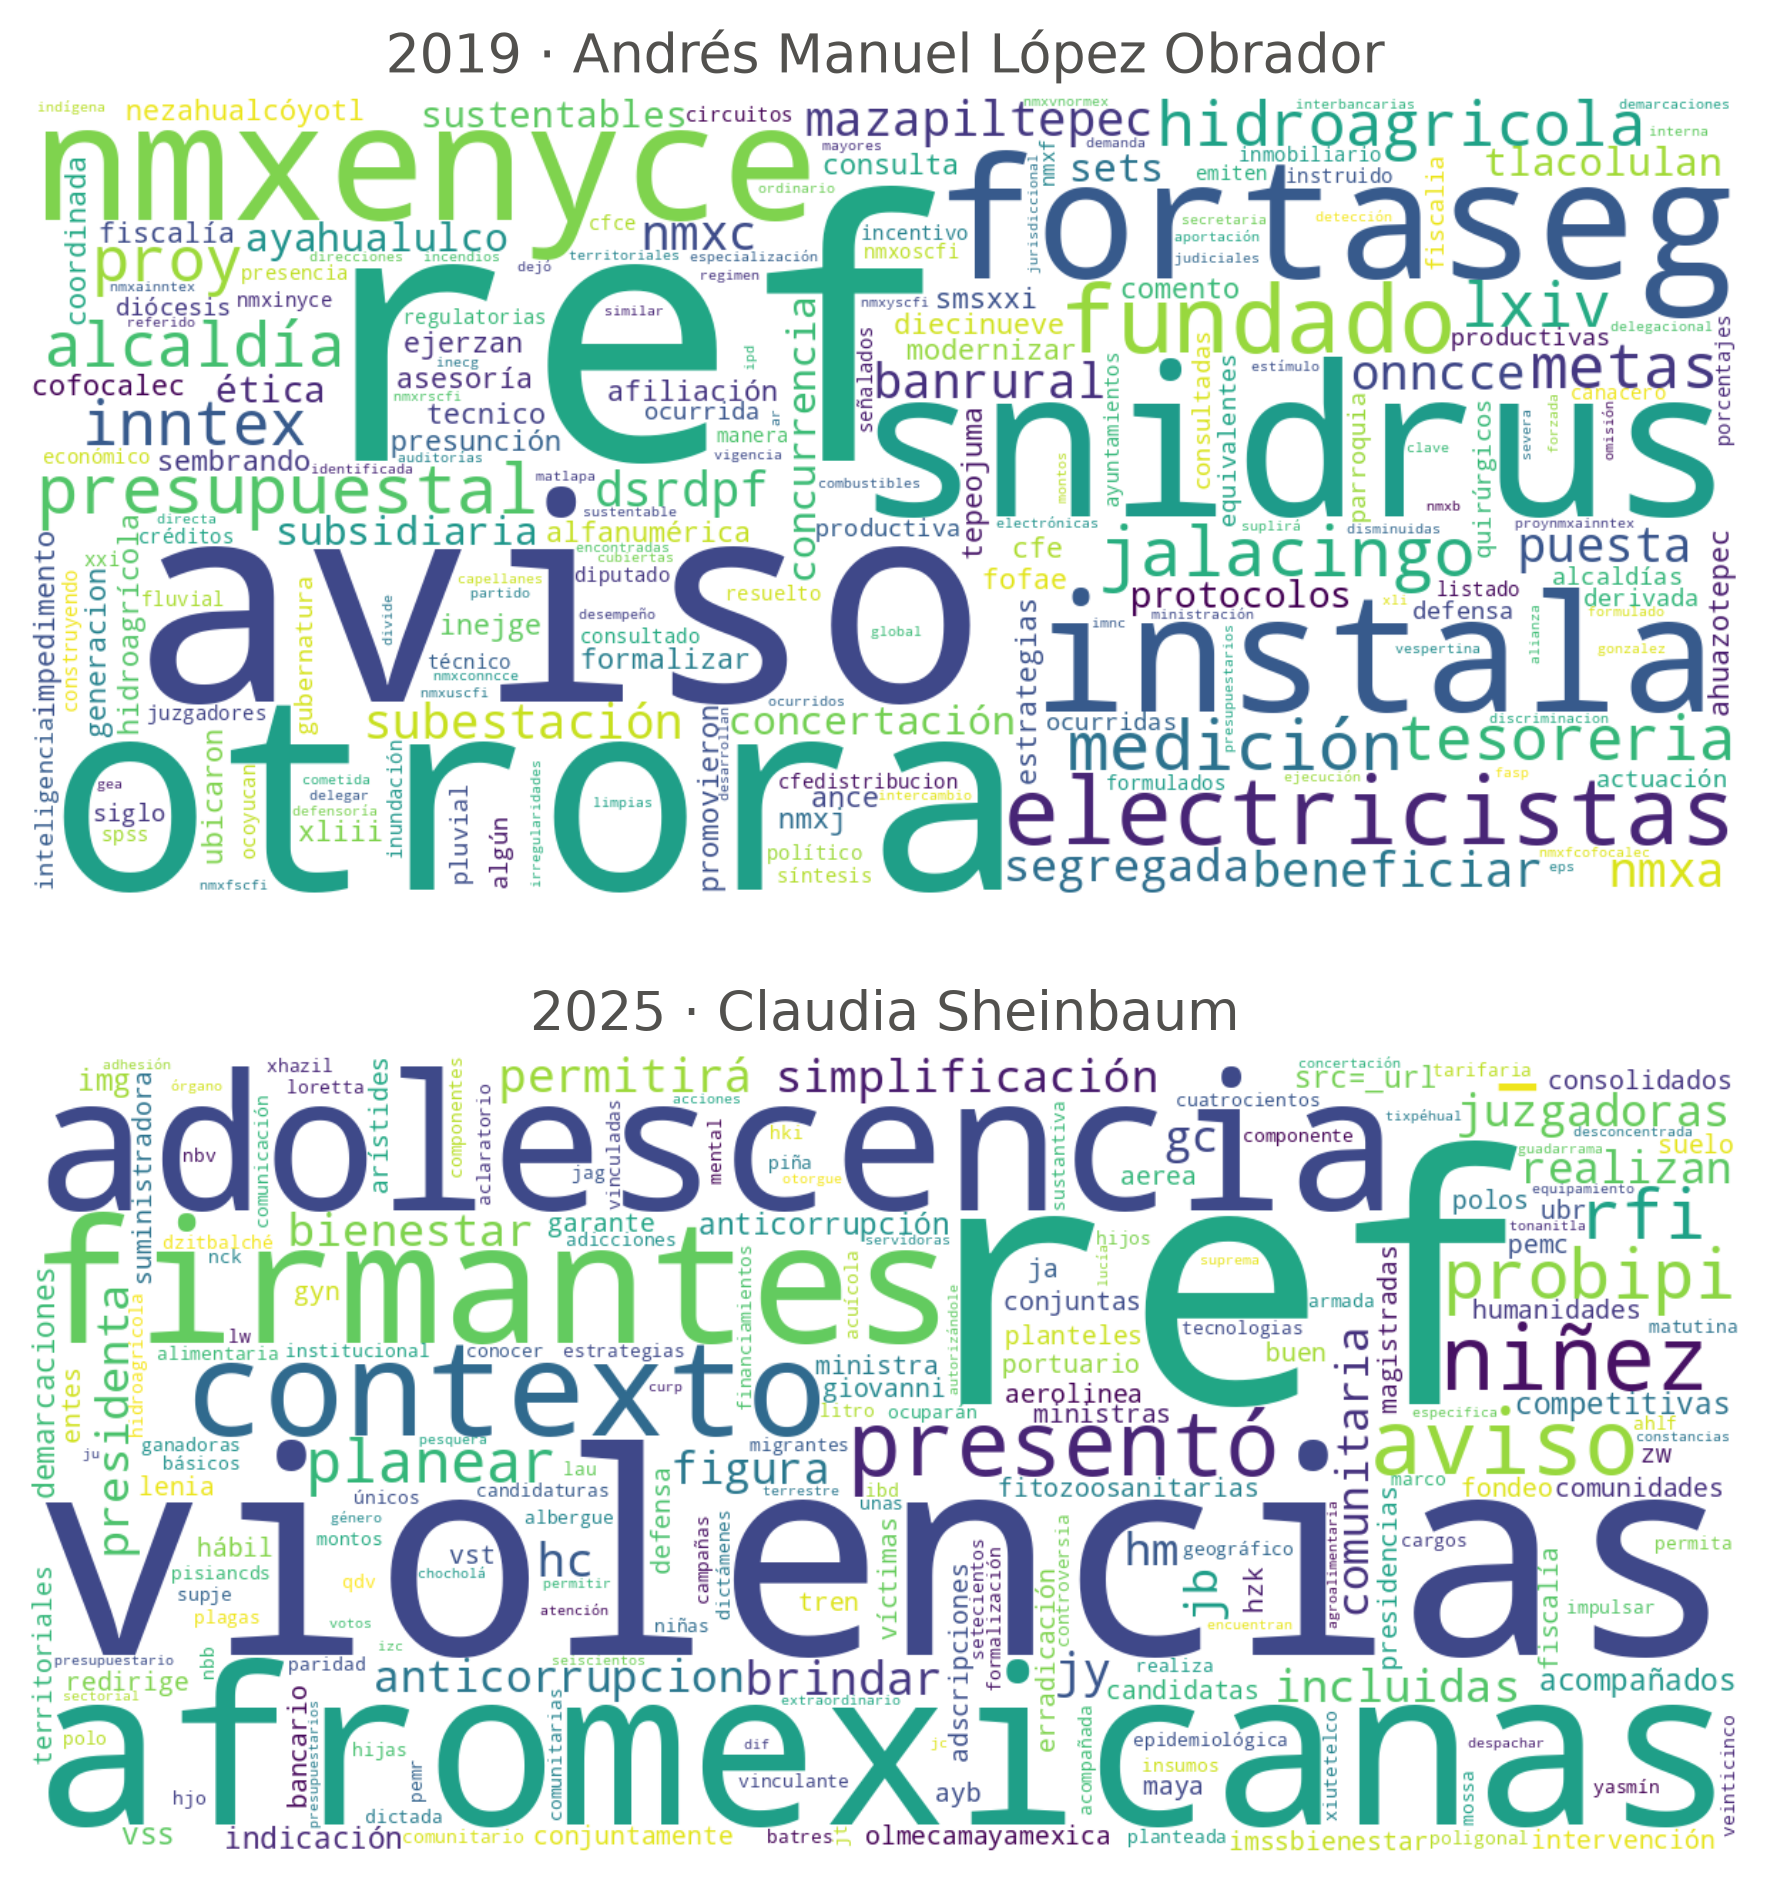

In [10]:
#| label: fig-first-year
#| fig-cap: "Terms that most identify each year against the whole 1917–2025 archive, sized by the ratio of their tf-idf idf in the rest of the archive to their idf that year. Top: 2019 (first year of López Obrador); bottom: 2025 (first year of Sheinbaum)."
from wordcloud import WordCloud

params = dict(del_diac=False, num_option="delete", token_min_filter=4)
casos = [(2019, "2019 · Andrés Manuel López Obrador"), (2025, "2025 · Claudia Sheinbaum")]

fig, axes = plt.subplots(2, 1, figsize=(8, 7.6))
for (year, titulo), ax in zip(casos, axes):
    pesos = pesos_discriminantes(year, **params)
    wc = WordCloud(
        width=1200, height=560, background_color="white", random_state=42
    ).generate_from_frequencies(pesos)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(titulo, color=INK, fontsize=13)
    ax.axis("off")
plt.show()

## What comes next

This exploration deliberately confined itself to the shallowest metadata in
the archive, and even so the titles sufficed to date the digitization of the
gazette, to measure the twilight of the land reform and to document the
bureaucratization of its content. The tf-idf contrast behind those word clouds
is a first step toward the next installments: the automatic classification of the
documentary types that the first word only approximates, and the full text of
the notes, whose conversion to Markdown — with the
[nota2md](https://pypi.org/project/nota2md/) and
[dof2md](https://pypi.org/project/dof2md/) packages, now available on PyPI —
is under way.

## Methodological note {.unnumbered .appendix}

The data comes from the DOF's open-data JSON service, queried day by day
between January 1, 1917 and December 31, 2025. The aggregates behind the figures
and the table are produced by
[`website/scripts/aggregate_titles.py`](https://github.com/INGEOTEC/LegalIA/blob/master/website/scripts/aggregate_titles.py)
and are versioned alongside this document, so the page can be rebuilt without
the raw archive; when the notebook runs outside the repository (for example on
Google Colab) it fetches them directly from GitHub. For the lexical analysis,
terms were lowercased and stripped of accents, and words shorter than three
characters, Spanish function words and the "REF" docket marker were discarded.

The two word clouds are the one figure not built from those CSVs: they need
the individual title strings, which
[`dofjson.titulos.download_titulos`](https://pypi.org/project/dofjson/)
fetches from the `notas-archivo` release at run time (the daily index only,
never the note contents) before microtc fits, for each year, a tf-idf model
of that year against one of the rest. It is the only step that reaches beyond
the committed aggregates.

This exploration was carried out by the LegalIA team together with Claude,
Anthropic's coding assistant, through
[Claude Code](https://claude.com/claude-code): the assistant implemented the
aggregation script that tokenizes and counts the titles, the download-and-
tf-idf pipeline behind the word clouds, produced the figures and drafted the
accompanying analysis. The authors verified the resulting
numbers against the archive and are responsible for the interpretations
advanced here.